# VTU to VTU Registration — ANTsPy SyNRA
> Both fixed and moving are `.vtu` meshes. No `.nii.gz` needed.

| Cell | Stage |
|------|-------|
| 1 | Install |
| 2 | Config |
| 3 | Load both VTU + voxelize |
| 4 | ANTsPy SyNRA registration |
| 4b | Overlay visualisation |
| 5 | Apply warp to mesh nodes -> new `.vtu` |
| 6 | Validate + output summary |

**SyNRA** = Rigid + Affine + SyN diffeomorphic warp — gold standard for anatomical registration.
The displacement field is applied directly to mesh node coordinates via `ants.apply_transforms_to_points()`.


In [4]:
pip install antspyx pyvista numpy matplotlib SimpleITK pandas

Note: you may need to restart the kernel to use updated packages.


In [15]:
import os

export_folder = '/run/media/asusry7/Extreme SSD/2d_3d_regis dataset/New_version/Data/outputs/vtk_export'

print("Files in folder:")
for f in sorted(os.listdir(export_folder)):
    full = os.path.join(export_folder, f)
    size = os.path.getsize(full) / 1e6
    print(f"  {f:<60} {size:.1f} MB")

Files in folder:
  Head_V6.vtu                                                  9.7 MB
  Head_V6_metadata.json                                        0.0 MB
  ImageToStl.com_head_voxels.vtu                               9.7 MB
  ImageToStl.com_head_voxels_transform.vtu                     56.2 MB
  part_distribution.png                                        0.1 MB
  parts                                                        1.0 MB


In [16]:
!pip install antspyx pyvista numpy matplotlib SimpleITK pandas -q

import ants
import pyvista as pv
import numpy as np
import SimpleITK as sitk
import matplotlib.pyplot as plt
import pandas as pd
import os, time

print(f'ants    : {ants.__version__}')
print(f'pyvista : {pv.__version__}')
print(f'numpy   : {np.__version__}')


ants    : 0.6.3
pyvista : 0.48.4
numpy   : 2.2.5


## Cell 2 — Config

In [ ]:
# USER EDIT
FIXED_VTU  = r'/run/media/asusry7/Extreme SSD/2d_3d_regis dataset/New_version/Data/outputs/vtk_export/ImageToStl.com_head_voxels_transform_2.vtu'    # reference/template mesh
MOVING_VTU = r'/run/media/asusry7/Extreme SSD/2d_3d_regis dataset/New_version/Data/outputs/vtk_export/Head_V6.vtu'   # subject mesh to warp
OUTPUT_DIR = 'outputs/synra'

VOXEL_SIZE_MM = 1.0      # voxelization resolution in mm
SYN_TYPE      = 'SyNRA'  # 'SyNRA'=Rigid+Affine+SyN | 'SyN' | 'Affine'

os.makedirs(OUTPUT_DIR, exist_ok=True)
stem = os.path.splitext(os.path.basename(MOVING_VTU))[0]

print(f'Fixed  : {FIXED_VTU}   exists={os.path.exists(FIXED_VTU)}')
print(f'Moving : {MOVING_VTU}  exists={os.path.exists(MOVING_VTU)}')
print(f'Output : {OUTPUT_DIR}')
print(f'Method : {SYN_TYPE}')


Fixed  : /run/media/asusry7/Extreme SSD/2d_3d_regis dataset/New_version/Data/outputs/vtk_export/ImageToStl.com_head_voxels_transform.vtu   exists=True
Moving : /run/media/asusry7/Extreme SSD/2d_3d_regis dataset/New_version/Data/outputs/vtk_export/Head_V6.vtu  exists=True
Output : outputs/synra
Method : SyNRA


## Cell 3 — Load Both VTU + Voxelize

Converts both meshes to voxel volumes for ANTsPy.
- **Auto-scale**: detects mm vs m unit mismatch and corrects it
- **Gaussian blur**: softens binary volumes so SyN has smooth gradients to follow
- **Margin**: pads bounding box so mesh is not clipped at volume edge


In [18]:
def load_vtu(path):
    mesh  = pv.read(path)
    nodes = np.array(mesh.points, dtype=np.float64)
    print(f'  Points : {len(nodes):,}')
    print(f'  Cells  : {mesh.n_cells:,}')
    print(f'  Bounds X: [{nodes[:,0].min():.3f}, {nodes[:,0].max():.3f}]')
    print(f'  Bounds Y: [{nodes[:,1].min():.3f}, {nodes[:,1].max():.3f}]')
    print(f'  Bounds Z: [{nodes[:,2].min():.3f}, {nodes[:,2].max():.3f}]')
    return mesh, nodes


def auto_rescale(nodes_moving, nodes_fixed):
    """
    Rescale moving bounding box to match fixed.
    Handles mm vs m vs cm unit mismatches automatically.
    """
    ext_f = nodes_fixed.max(axis=0)  - nodes_fixed.min(axis=0)
    ext_m = nodes_moving.max(axis=0) - nodes_moving.min(axis=0)
    scale = float(np.median(ext_f / (ext_m + 1e-8)))
    print(f'  Fixed  extent : {ext_f.round(2)}')
    print(f'  Moving extent : {ext_m.round(2)}')
    print(f'  Scale factor  : {scale:.4f}')
    if 0.8 < scale < 1.2:
        print('  Units match — no rescaling needed')
        return nodes_moving, 1.0
    c = nodes_moving.mean(axis=0)
    print(f'  Rescaling moving by {scale:.4f} to match fixed space')
    return (nodes_moving - c) * scale + c, scale


def voxelize_to_ants(nodes, voxel_size=1.0, margin_mm=10.0, sigma=2.0, tmp_path=None):
    """
    Point cloud -> binary volume -> Gaussian blur -> ANTs image.
    sigma blur is critical: SyN needs smooth gradients, not hard binary edges.
    """
    mins = nodes.min(axis=0) - margin_mm
    maxs = nodes.max(axis=0) + margin_mm
    dims = np.ceil((maxs - mins) / voxel_size).astype(int)
    vol  = np.zeros(dims[::-1], dtype=np.float32)
    idx  = np.clip(np.floor((nodes - mins) / voxel_size).astype(int), 0, dims-1)
    vol[idx[:,2], idx[:,1], idx[:,0]] = 1.0

    sitk_img = sitk.GetImageFromArray(vol)
    sitk_img.SetSpacing([voxel_size]*3)
    sitk_img.SetOrigin(mins.tolist())
    if sigma > 0:
        sitk_img = sitk.SmoothingRecursiveGaussian(sitk_img, sigma=sigma)
    sitk.WriteImage(sitk_img, tmp_path)
    return ants.image_read(tmp_path)


# Load
print('Loading FIXED VTU...')
fixed_mesh,  nodes_fixed  = load_vtu(FIXED_VTU)
print('\nLoading MOVING VTU...')
moving_mesh, nodes_moving = load_vtu(MOVING_VTU)

# Scale
print('\nAuto-scale check...')
nodes_moving_scaled, scale_factor = auto_rescale(nodes_moving, nodes_fixed)

# Voxelize
print(f'\nVoxelizing at {VOXEL_SIZE_MM} mm with Gaussian blur sigma=2.0...')
fixed_ants  = voxelize_to_ants(nodes_fixed,
                               voxel_size=VOXEL_SIZE_MM, sigma=2.0,
                               tmp_path=os.path.join(OUTPUT_DIR,'fixed_voxelized.nii.gz'))
moving_ants = voxelize_to_ants(nodes_moving_scaled,
                               voxel_size=VOXEL_SIZE_MM, sigma=2.0,
                               tmp_path=os.path.join(OUTPUT_DIR,'moving_voxelized.nii.gz'))

print(f'Fixed  ANTs : {fixed_ants.shape}')
print(f'Moving ANTs : {moving_ants.shape}')
print('Voxelization complete.')


Loading FIXED VTU...
  Points : 405,210
  Cells  : 816,040
  Bounds X: [-0.500, 172.500]
  Bounds Y: [-0.500, 253.500]
  Bounds Z: [-0.500, 226.500]

Loading MOVING VTU...
  Points : 179,676
  Cells  : 256,571
  Bounds X: [-283.356, -52.307]
  Bounds Y: [-82.595, 82.595]
  Bounds Z: [519.142, 770.890]

Auto-scale check...
  Fixed  extent : [173. 254. 227.]
  Moving extent : [231.05 165.19 251.75]
  Scale factor  : 0.9017
  Units match — no rescaling needed

Voxelizing at 1.0 mm with Gaussian blur sigma=2.0...
Fixed  ANTs : (193, 274, 247)
Moving ANTs : (252, 186, 272)
Voxelization complete.


## Cell 4 — ANTsPy SyNRA Registration

`SyNRA` runs three stages internally:
1. **Rigid** — rotation + translation (6 DOF)
2. **Affine** — + scale + shear (12 DOF)
3. **SyN** — diffeomorphic non-linear warp field

The output is a composite transform: `[warp_field.nii.gz, affine.mat]`


In [19]:
print(f'Running ANTsPy {SYN_TYPE} registration...')
print('This may take 2-5 minutes.\n')
t0 = time.time()

result = ants.registration(
    fixed   = fixed_ants,
    moving  = moving_ants,
    type_of_transform = SYN_TYPE,

    # Metric: meansquares works far better than MI on binary/sparse volumes
    syn_metric     = 'meansquares',
    syn_sampling   = 0.5,

    # Iterations per resolution level (coarse -> fine)
    # Increase first number if registration is not converging
    reg_iterations = (200, 100, 50),

    # Regularization: higher flow_sigma = smoother, less local warp
    # For rigid head shapes: 3.0 is a good starting point
    flow_sigma     = 3,
    total_sigma    = 0,

    # Affine stage settings
    aff_metric     = 'meansquares',
    aff_sampling   = 32,
    aff_iterations = (2100, 1200, 200, 0),

    grad_step      = 0.1,
    verbose        = True,
)

elapsed = time.time() - t0
print(f'\nDone in {elapsed:.1f}s ({elapsed/60:.1f} min)')
print('\nTransform files:')
for tf in result['fwdtransforms']:
    print(f'  {tf}')

# Save warped volume
warped_path = os.path.join(OUTPUT_DIR, 'moving_warped_synra.nii.gz')
ants.image_write(result['warpedmovout'], warped_path)
print(f'\nWarped volume -> {warped_path}')


Running ANTsPy SyNRA registration...
This may take 2-5 minutes.

antsRegistration --dimensionality 3 -r [0x7f83a6fd8988,0x7f83a6fd8828,1] --metric meansquares[0x7f83a6fd8988,0x7f83a6fd8828,1,32,regular,0.2] --transform Rigid[0.25] --convergence 2100x1200x1200x0 --smoothing-sigmas 3x2x1x0 --shrink-factors 4x2x2x1 -x [NA,NA] --metric meansquares[0x7f83a6fd8988,0x7f83a6fd8828,1,32,regular,0.2] --transform Affine[0.25] --convergence 2100x1200x1200x0 --smoothing-sigmas 3x2x1x0 --shrink-factors 4x2x2x1 -x [NA,NA] --metric meansquares[0x7f83a6fd8988,0x7f83a6fd8828,1,0.5] --transform SyN[0.100000,3.000000,0.000000] --convergence [200x100x50,1e-7,8] --smoothing-sigmas 2x1x0 --shrink-factors 4x2x1 -u 0 -z 1 --output [/tmp/tmpn027r694,0x7f83a6fdb228,0x7f83a6fdbec8] -x [NA,NA] --float 1 --write-composite-transform 0 -v 1
All_Command_lines_OK
Using single precision for computations.
The composite transform comprises the following transforms (in order): 
  1. Center of mass alignment using fixed ima

## Cell 4b — Visualise Registration Result

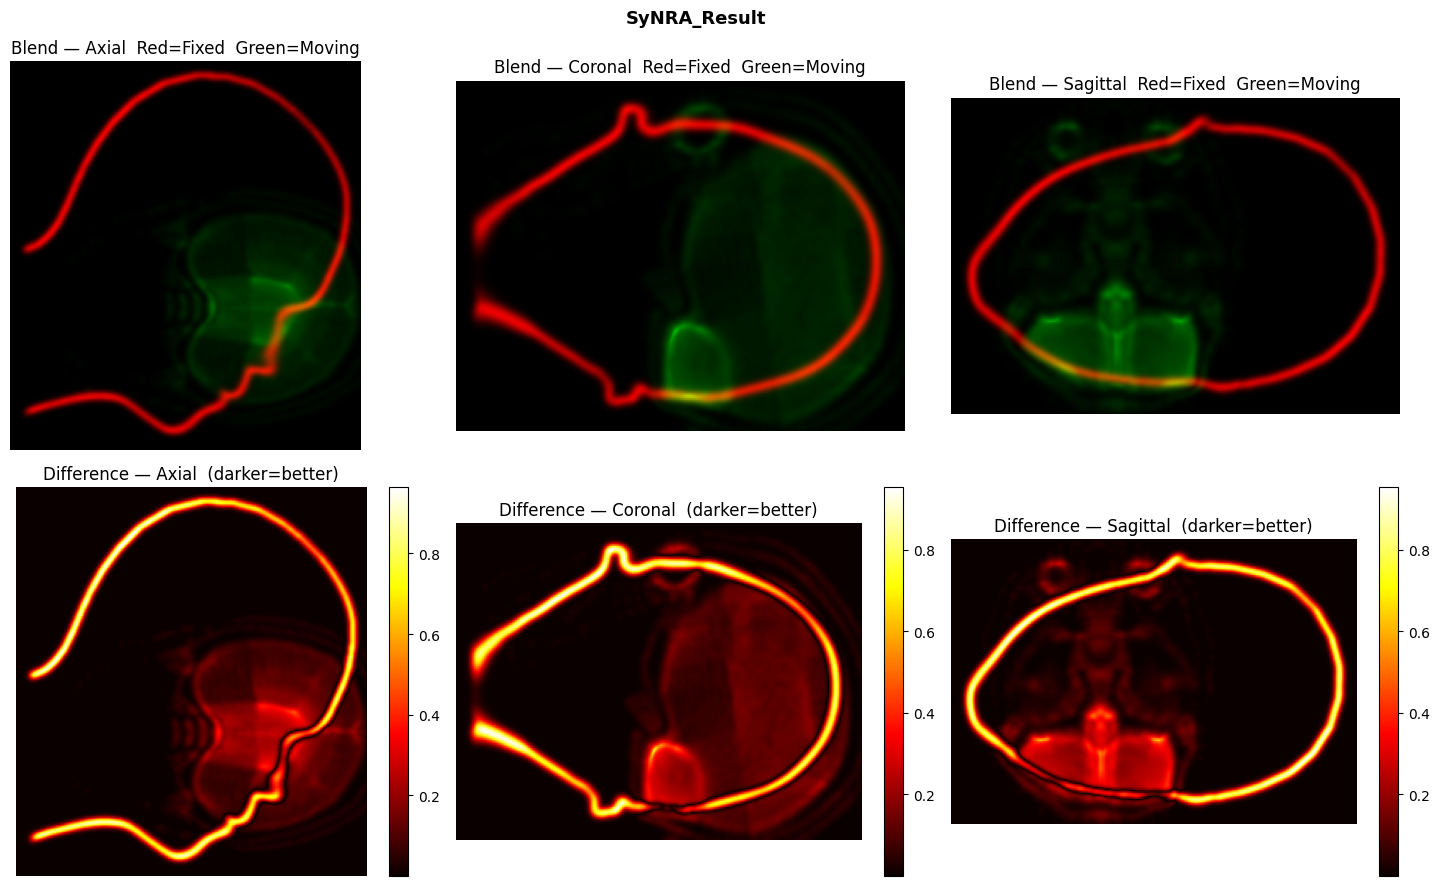

Saved -> outputs/synra/SyNRA_Result.png

Dice : 0.1362  (1.0 = perfect overlap)
IoU  : 0.0731
FAIL -- check scale_factor or mesh orientation


In [20]:
def norm(a):
    a = a.astype(np.float32)
    return (a - a.min()) / (a.max() - a.min() + 1e-8)


def show_synra_result(fixed_ants, warped_ants, title='SyNRA_Result'):
    f_arr = norm(fixed_ants.numpy())
    m_arr = norm(warped_ants.numpy())
    z, y, x = [d//2 for d in f_arr.shape]
    views = [
        (f_arr[z,:,:], m_arr[z,:,:], 'Axial'),
        (f_arr[:,y,:], m_arr[:,y,:], 'Coronal'),
        (f_arr[:,:,x], m_arr[:,:,x], 'Sagittal'),
    ]
    fig, axes = plt.subplots(2, 3, figsize=(15, 9))
    fig.suptitle(title, fontsize=13, fontweight='bold')
    for col, (fs, ms, label) in enumerate(views):
        rgb = np.zeros((*fs.shape, 3), dtype=np.float32)
        rgb[...,0] = fs; rgb[...,1] = ms
        axes[0,col].imshow(rgb, origin='lower')
        axes[0,col].set_title(f'Blend — {label}  Red=Fixed  Green=Moving')
        axes[0,col].axis('off')
        diff = np.abs(fs - ms)
        im = axes[1,col].imshow(diff, cmap='hot', origin='lower')
        plt.colorbar(im, ax=axes[1,col], fraction=0.046)
        axes[1,col].set_title(f'Difference — {label}  (darker=better)')
        axes[1,col].axis('off')
    plt.tight_layout()
    out = os.path.join(OUTPUT_DIR, f'{title}.png')
    plt.savefig(out, dpi=120); plt.show()
    print(f'Saved -> {out}')


show_synra_result(fixed_ants, result['warpedmovout'])

# Dice + IoU
f_bin = (fixed_ants.numpy()  > 0.1).astype(np.float32)
m_bin = (result['warpedmovout'].numpy() > 0.1).astype(np.float32)
intersection = (f_bin * m_bin).sum()
dice = 2 * intersection / (f_bin.sum() + m_bin.sum() + 1e-8)
iou  = intersection / (np.clip(f_bin + m_bin, 0, 1).sum() + 1e-8)
print(f'\nDice : {dice:.4f}  (1.0 = perfect overlap)')
print(f'IoU  : {iou:.4f}')
if dice >= 0.85:   print('PASS -- excellent')
elif dice >= 0.70: print('MARGINAL -- try increasing reg_iterations or reducing flow_sigma')
else:              print('FAIL -- check scale_factor or mesh orientation')


## Cell 5 — Apply SyNRA Warp to Mesh Nodes → New `.vtu`

`ants.apply_transforms_to_points()` applies the full composite transform
(SyN warp field + affine matrix) directly to point coordinates.
All original cell/point/field data arrays are preserved via deep copy.
A `displacement_mm` array is added so you can colour the mesh in ParaView.


In [21]:
print(f'Applying SyNRA transform to {len(nodes_moving_scaled):,} nodes...')
t0 = time.time()

# Build DataFrame of scaled node coordinates
pts_df = pd.DataFrame(nodes_moving_scaled, columns=['x','y','z'])

# Apply the full forward transform (warp field + affine)
pts_warped_df = ants.apply_transforms_to_points(
    dim           = 3,
    points        = pts_df,
    transformlist = result['fwdtransforms'],
    whichtoinvert = [False] * len(result['fwdtransforms']),
)

nodes_reg_scaled = pts_warped_df[['x','y','z']].values.astype(np.float64)
print(f'Done in {time.time()-t0:.2f}s')

# Undo scale factor -> back to original mesh coordinate space
c = nodes_reg_scaled.mean(axis=0)
nodes_registered = (nodes_reg_scaled - c) / scale_factor + c

# Displacement stats
displacements = np.linalg.norm(nodes_registered - nodes_moving, axis=1)
print(f'\nDisplacement stats:')
print(f'  Mean : {displacements.mean():.4f}')
print(f'  Max  : {displacements.max():.4f}')
print(f'  Std  : {displacements.std():.4f}')

# Build registered VTU — deep copy preserves all arrays
registered_mesh = moving_mesh.copy(deep=True)
registered_mesh.points = nodes_registered
registered_mesh.point_data['displacement_mm'] = displacements.astype(np.float32)

out_vtu = os.path.join(OUTPUT_DIR, f'{stem}_synra_registered.vtu')
registered_mesh.save(out_vtu, binary=True)

fsize = os.path.getsize(out_vtu) / 1e6
print(f'\nSaved -> {out_vtu}  ({fsize:.1f} MB)')
print(f'  Points       : {registered_mesh.n_points:,}')
print(f'  Cells        : {registered_mesh.n_cells:,}')
print(f'  Point arrays : {list(registered_mesh.point_data.keys())}')
print(f'  Cell  arrays : {list(registered_mesh.cell_data.keys())}')

# Round-trip sanity check
chk = pv.read(out_vtu)
err = np.max(np.abs(chk.points - nodes_registered))
print(f'\nRound-trip error : {err:.2e}  {"PASS" if err < 1e-6 else "WARN"}')


Applying SyNRA transform to 179,676 nodes...
Done in 0.77s

Displacement stats:
  Mean : 592.0443
  Max  : 602.9669
  Std  : 4.3126

Saved -> outputs/synra/Head_V6_synra_registered.vtu  (8.6 MB)
  Points       : 179,676
  Cells        : 256,571
  Point arrays : ['node_id', 'displacement_mm']
  Cell  arrays : ['element_id', 'part_id', 'material_id', 'section_id', 'element_type_code']

Round-trip error : 0.00e+00  PASS


## Cell 6 — Final Validation + Output Summary

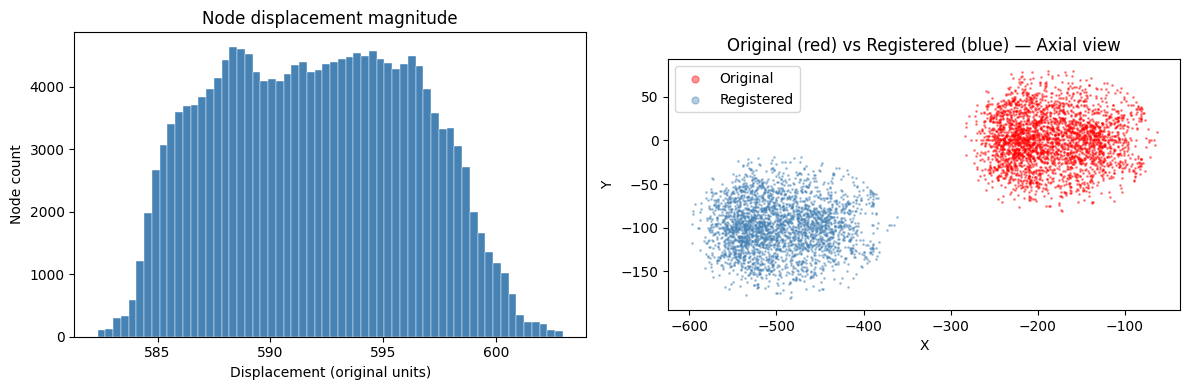

OUTPUT FILES:
  Head_V6_synra_registered.vtu                         8.6 MB
  SyNRA_Result.png                                     0.5 MB
  fixed_voxelized.nii.gz                               50.7 MB
  moving_voxelized.nii.gz                              48.8 MB
  moving_warped_synra.nii.gz                           32.9 MB
  validation_displacement.png                          0.1 MB

KEY OUTPUT : Head_V6_synra_registered.vtu
  Open in ParaView alongside fixed_head.vtu
  Colour by displacement_mm to visualise warp magnitude


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Displacement histogram
axes[0].hist(displacements, bins=60, color='steelblue', edgecolor='white', linewidth=0.3)
axes[0].set_xlabel('Displacement (original units)')
axes[0].set_ylabel('Node count')
axes[0].set_title('Node displacement magnitude')

# Axial scatter: original vs registered
sample = np.random.choice(len(nodes_moving), min(3000, len(nodes_moving)), replace=False)
axes[1].scatter(nodes_moving[sample,0], nodes_moving[sample,1],
                s=1, c='red',  alpha=0.4, label='Original')
axes[1].scatter(nodes_registered[sample,0], nodes_registered[sample,1],
                s=1, c='steelblue', alpha=0.4, label='Registered')
axes[1].set_aspect('equal')
axes[1].set_xlabel('X'); axes[1].set_ylabel('Y')
axes[1].set_title('Original (red) vs Registered (blue) — Axial view')
axes[1].legend(markerscale=5)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'validation_displacement.png'), dpi=120)
plt.show()

# File list
print('=' * 60)
print('OUTPUT FILES:')
for fname in sorted(os.listdir(OUTPUT_DIR)):
    fpath = os.path.join(OUTPUT_DIR, fname)
    fsize = os.path.getsize(fpath) / 1e6
    print(f'  {fname:<52} {fsize:.1f} MB')
print('=' * 60)
print(f'\nKEY OUTPUT : {stem}_synra_registered.vtu')
print('  Open in ParaView alongside fixed_head.vtu')
print('  Colour by displacement_mm to visualise warp magnitude')
